In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
import plasmidtools


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
MANUAL_DIR = DATA_DIR / "manual_annotations"

Pre-processed / pre-calculated data

In [3]:
plasmid_meta = pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
plasmid_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet")
plasmid_stats = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")


In [4]:
element_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_elements.parquet")
element_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_elements.parquet")
primer_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_primers.parquet")
primer_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_primers.parquet")

cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")

element_cre_overlap = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_element_cre_overlaps.parquet")
    .join(element_citations[["element_type", "element_name", "n_plasmids", "n_citations"]], left_on=["type", "name"], right_on=["element_type", "element_name"], how="left")
    .with_columns(pl.max_horizontal("tss_fwd_avg_signal", "tss_rev_avg_signal").alias("tss_avg_signal"))
)

primer_cre_overlap = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_primers_cre_overlaps.parquet")
    .join(primer_citations[["element_type", "element_name", "n_plasmids", "n_citations"]], left_on=["type", "name"], right_on=["element_type", "element_name"], how="left")
    .with_columns(pl.max_horizontal("tss_fwd_avg_signal", "tss_rev_avg_signal").alias("tss_avg_signal"))
)


**CRE-Element overlap statistics**

TSS Midpoints - CRE Midpoints axes

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


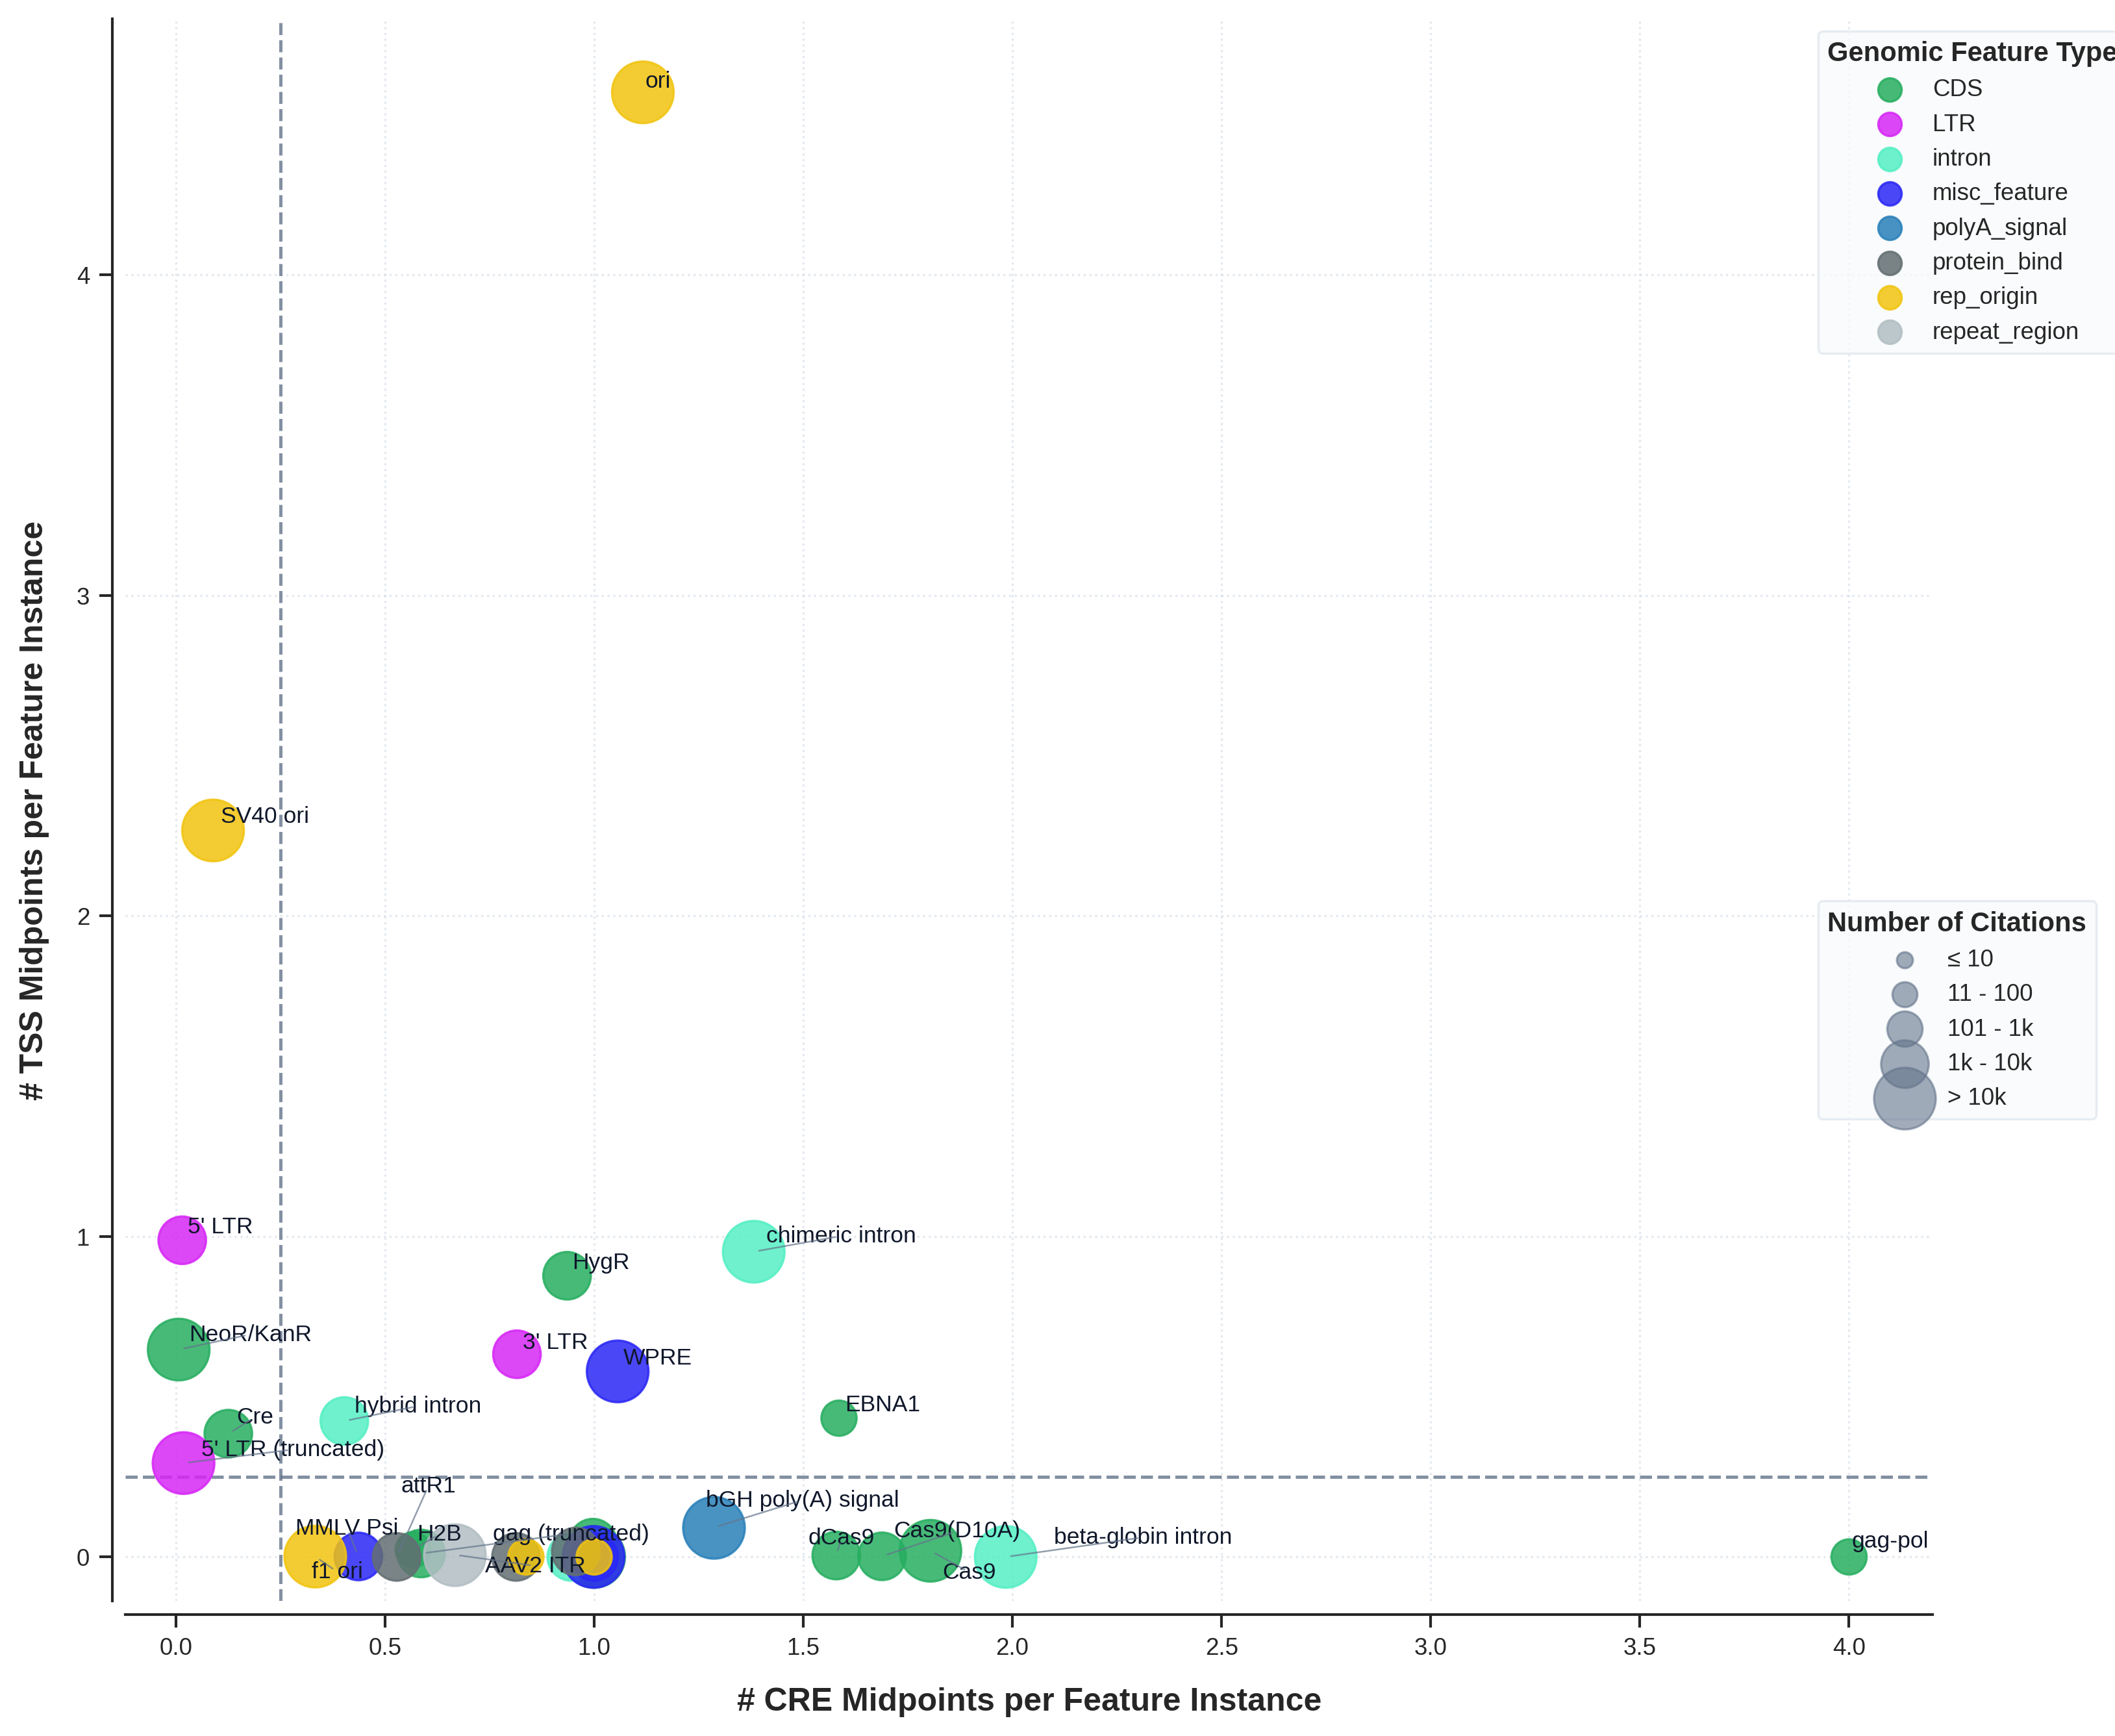

In [6]:
df = (
    element_cre_overlap
    .filter(~pl.col("type").is_in(["enhancer", "promoter"]))
    .filter(pl.col("n_citations") >= 500)
)

fig, ax = plasmidtools.statplots.plot_regulatory_correlation(
    df,
    x_col = "n_cre_midpoints", x_label = "# CRE Midpoints per Feature Instance", x_thresh = 0.25,
    y_col = "n_tss_midpoints", y_label = "# TSS Midpoints per Feature Instance", y_thresh = 0.25,
)
# fig.savefig(FIG_DIR / "mammalian_plasmid_cre_overlap.pdf", format="pdf", bbox_inches="tight")


Fraction of CRE base pairs - CRE activity axes

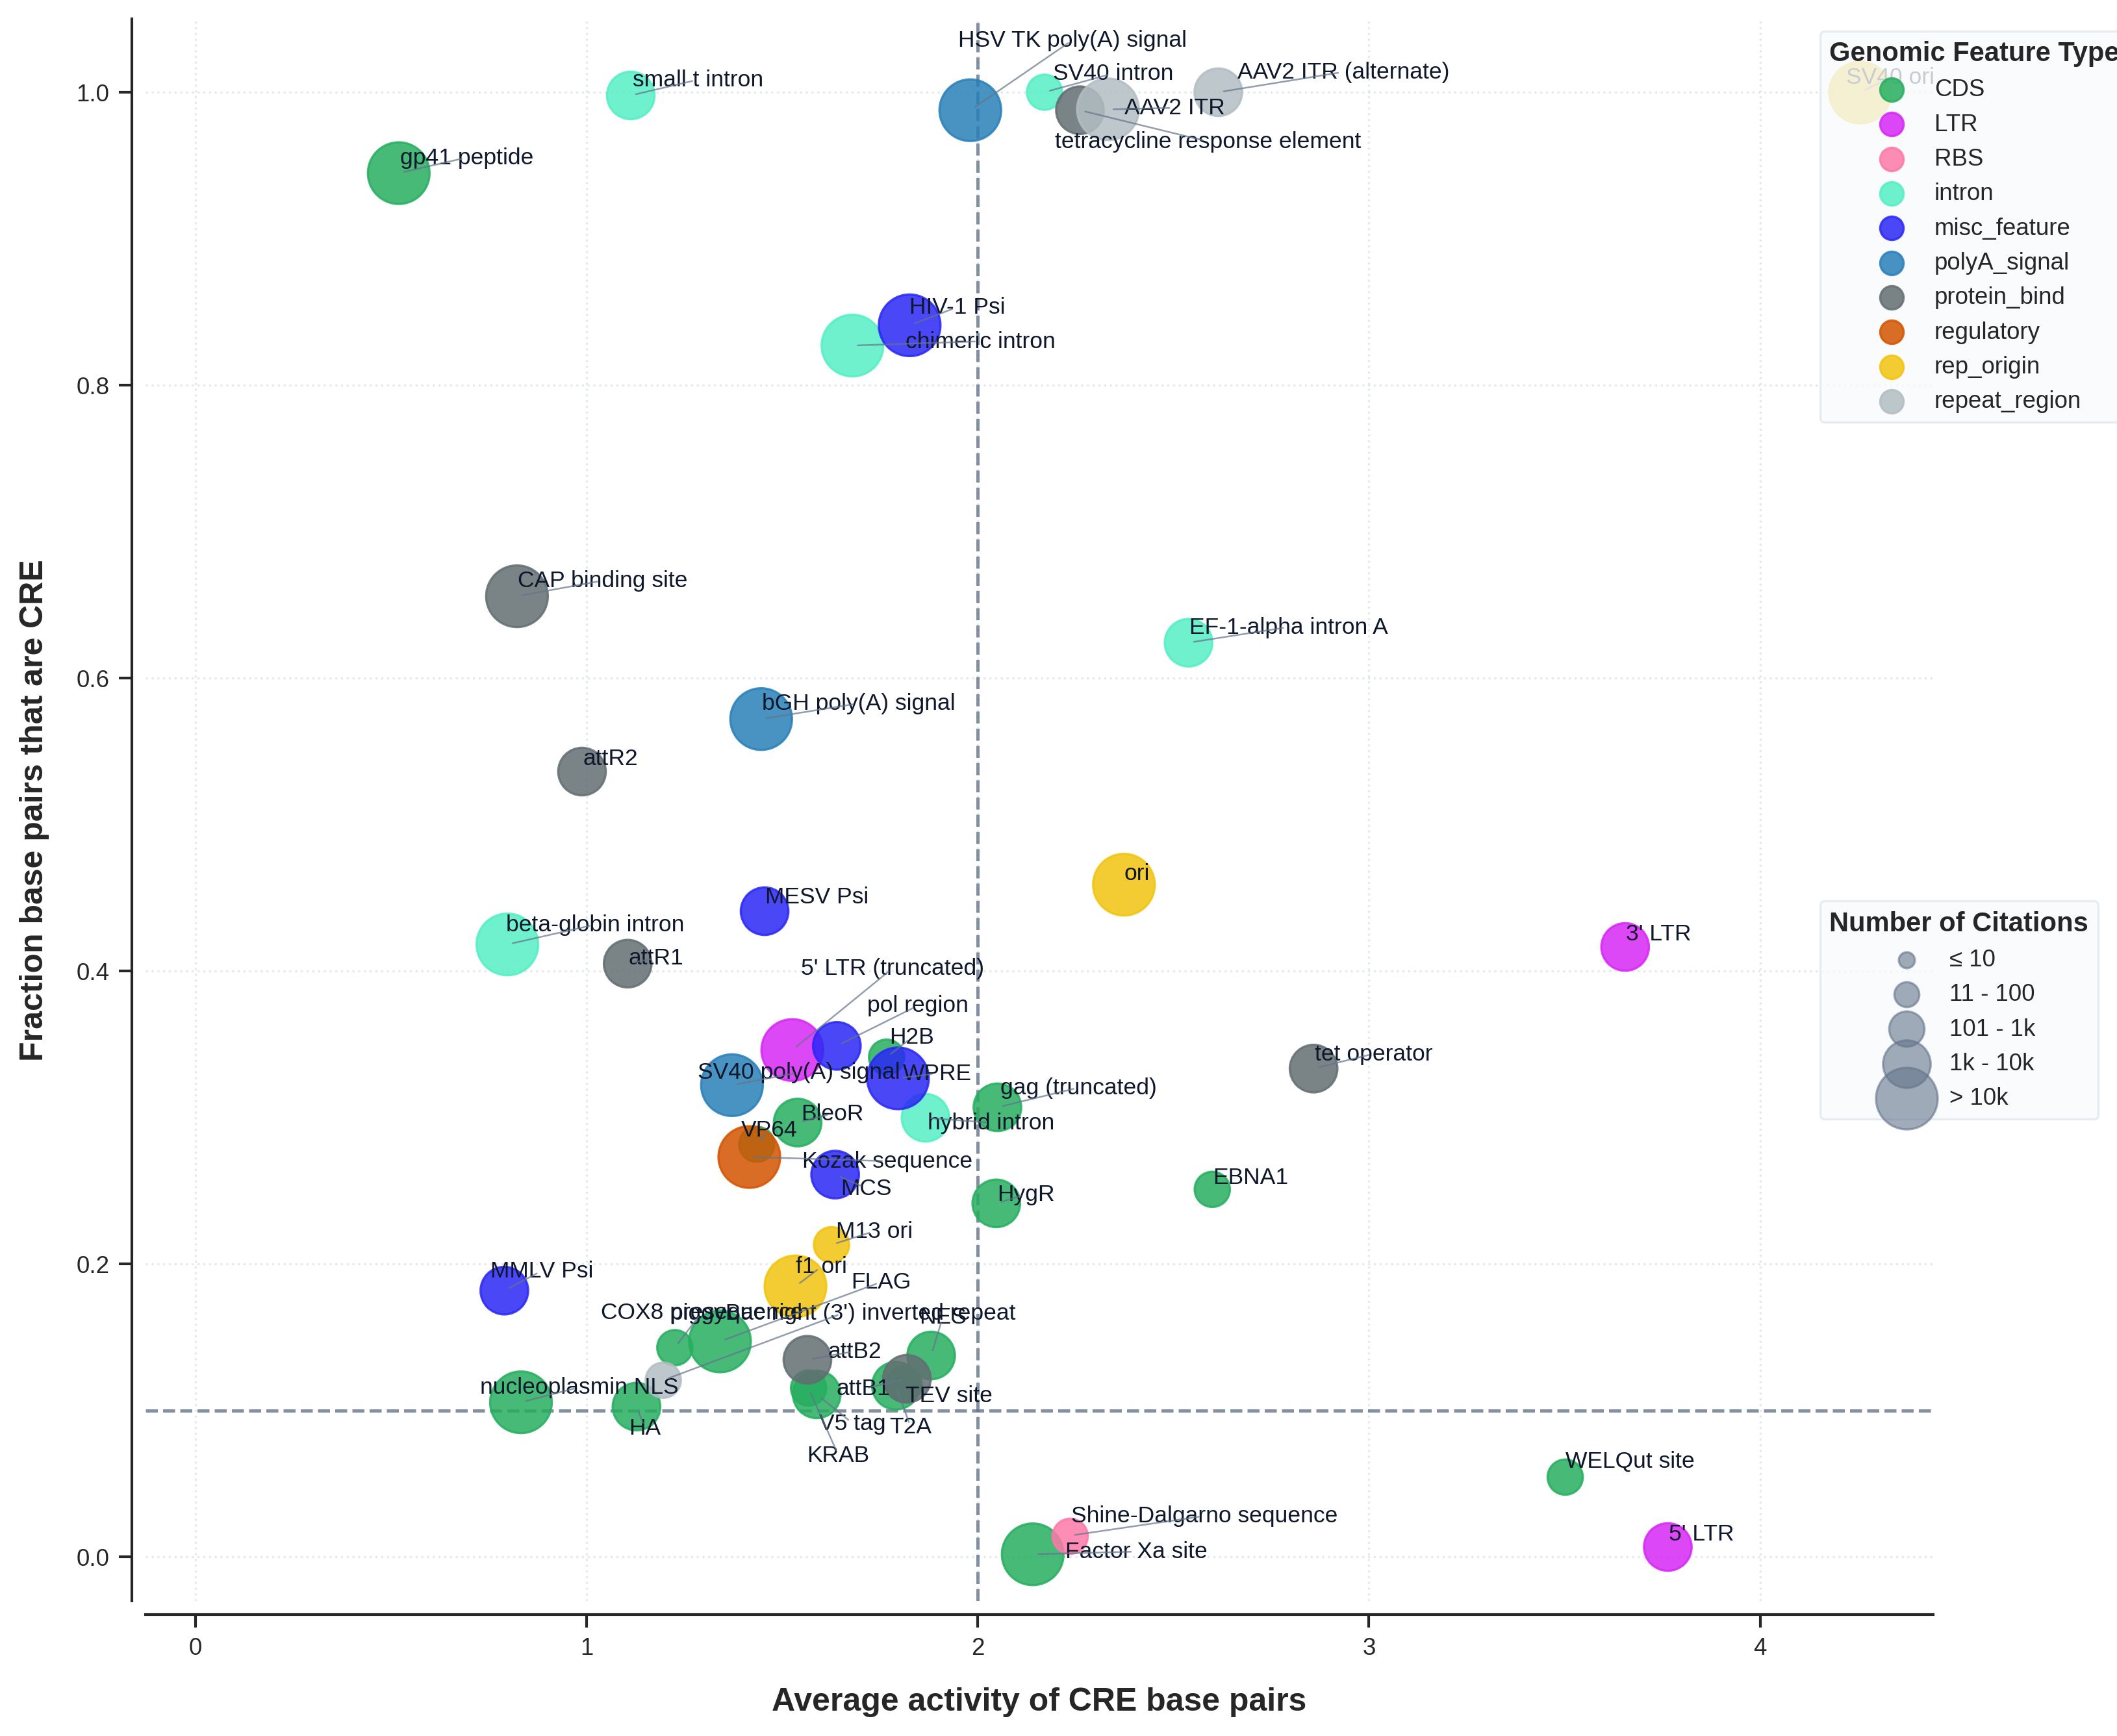

In [7]:
df = (
    element_cre_overlap
    .filter(~pl.col("type").is_in(["enhancer", "promoter"]))
    .filter(pl.col("n_citations") >= 500)
)

fig, ax = plasmidtools.statplots.plot_regulatory_correlation(
    df,
    x_col = "cre_avg_signal", x_label = "Average activity of CRE base pairs", x_thresh = 2,
    y_col = "fraction_cre_bp", y_label = "Fraction base pairs that are CRE", y_thresh = 0.1,
)


TSS Midpoints - TSS activity axes

In [10]:
df = (
    element_cre_overlap
    .filter(~pl.col("type").is_in(["enhancer", "promoter"]))
    .filter(pl.col("n_citations") >= 500)
)

fig, ax = plasmidtools.statplots.plot_regulatory_correlation(
    df,
    x_col = "tss_avg_signal", x_label = "Average activity of TSS base pairs", x_thresh = 0.1,
    y_col = "n_tss_midpoints", y_label = "# TSS Midpoints per Feature Instance", y_thresh = 0.25,
)
plt.close()


**Functional Profiles Clustering**

Text(0.5, 1.0, 'Candidate Cryptic CREs')

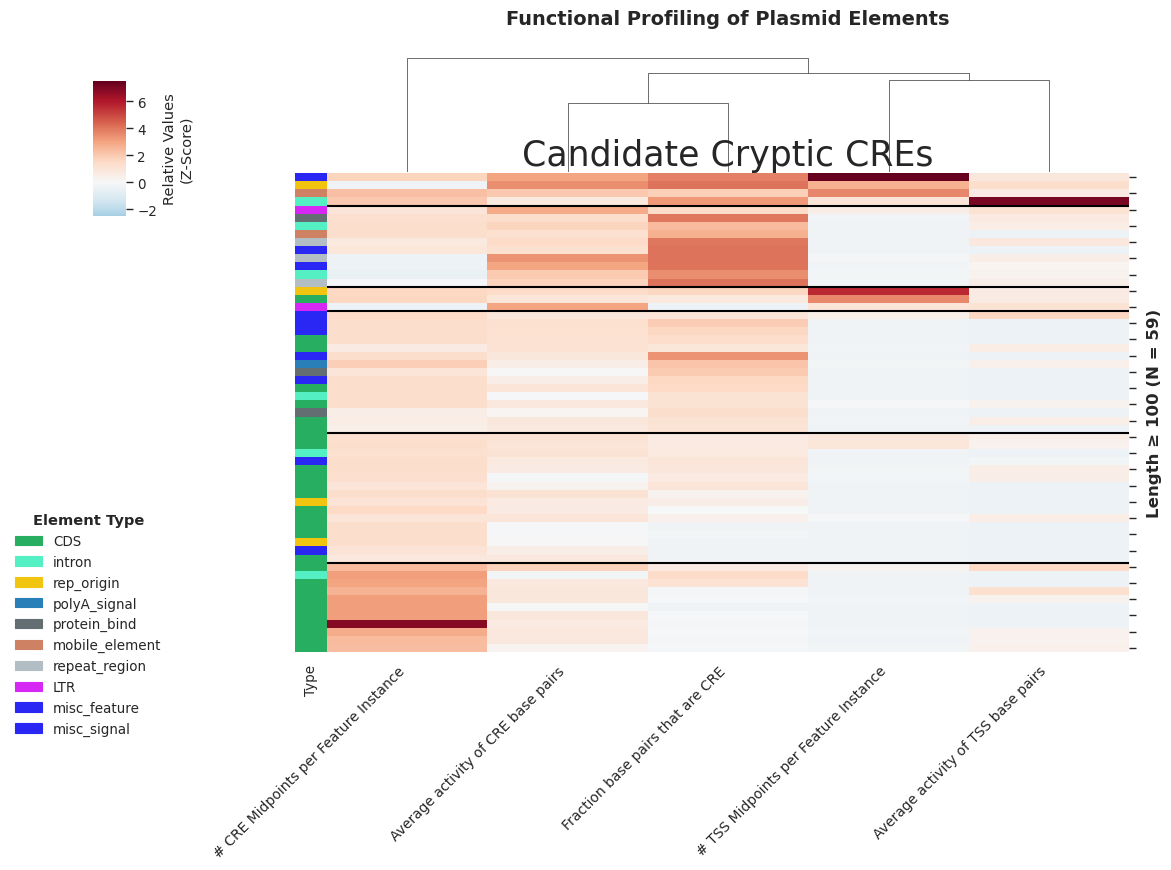

In [13]:
df_clustered = pl.read_csv(ADDGENE_DIR / "element_cre_overlap_clustering.csv")
df_heatmap = pl.read_csv(ADDGENE_DIR / "element_cre_overlap_clustering_heatmap.csv")
cryptic_cre_candidates = df_clustered.filter(df_clustered["is_cryptic_cre"])

# clust_df, heat_df = df_clustered, df_heatmap  # All
clust_df, heat_df = df_clustered.filter(df_clustered["is_cryptic_cre"]), df_heatmap.filter(df_clustered["is_cryptic_cre"])  # Cryptic CREs

cg = plasmidtools.statplots.functional_profiling_plot(clust_df, heat_df)
ax_heat = cg.ax_heatmap
ax_heat.set_ylabel(f"Length ≥ 100 (N = {len(clust_df)})", fontsize=12, fontweight='bold')
ax_heat.set_title("Candidate Cryptic CREs", fontsize=25)


In [16]:
cryptic_cre_candidates.head(15)

type,name,element_length,n_cre_midpoints,cre_avg_signal,fraction_cre_bp,n_tss_midpoints,tss_avg_signal,n_plasmids,n_citations,n_active_metrics,composite_z_score,priority_group,is_cryptic_cre
str,str,i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,i64,bool
"""misc_feature""","""Rosa26 left arm""",1083,1.166667,3.776475,0.939682,6.666667,0.097414,12,71,4,10.61529,1,true
"""rep_origin""","""SV40 ori""",136,0.089017,4.255907,0.999727,2.266741,0.138699,34641,42707,4,10.013455,1,true
"""mobile_element""","""IS1""",768,1.507246,2.868638,0.503434,3.043478,0.080524,69,136,4,9.076269,1,true
"""intron""","""chimeric intron""",379,1.381579,1.679551,0.827018,0.952352,0.587276,4784,13160,4,8.983924,1,true
"""LTR""","""3' LTR""",634,0.815499,3.655048,0.416437,0.632421,0.120348,2292,4079,5,6.92262,2,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""repeat_region""","""ITR""",103,0.013423,4.112663,1.0,0.107383,0.073786,81,195,2,6.0,2,true
"""misc_signal""","""Ad5 Psi""",151,0.051948,3.747996,0.994324,0.012987,0.044486,77,192,2,5.941542,2,true
"""intron""","""CMV intron""",110,0.0,2.851966,0.880952,0.095238,0.056424,21,156,2,4.98859,2,true


**CRE-Primer (buffer sequence) overlap statistics**

In [18]:
fig, ax = plasmidtools.statplots.plot_regulatory_correlation(
    primer_cre_overlap,
    x_col = "n_cre_midpoints", x_label = "# CRE Midpoints per Feature Instance", x_thresh=0.25,
    y_col = "n_tss_midpoints", y_label = "# TSS Midpoints per Feature Instance", y_thresh=0.25,
)
plt.close()


**Pile-ups**

In [12]:
PILEUP_PATH = ADDGENE_DIR / "plasmid_elements_prediction_pileups.h5"

element_type = "repeat_region"
element_name = "ITR"
(
    element_size, flank_size,
    type_matrix, cre_matrix, tss_fwd_matrix, tss_rev_matrix,
    pred_matrix, pred_fwd_matrix, pred_rev_matrix
) = plasmidtools.helpers.load_aligned_predictions_h5(element_type, element_name, PILEUP_PATH)



Element-aligned activity track pile ups

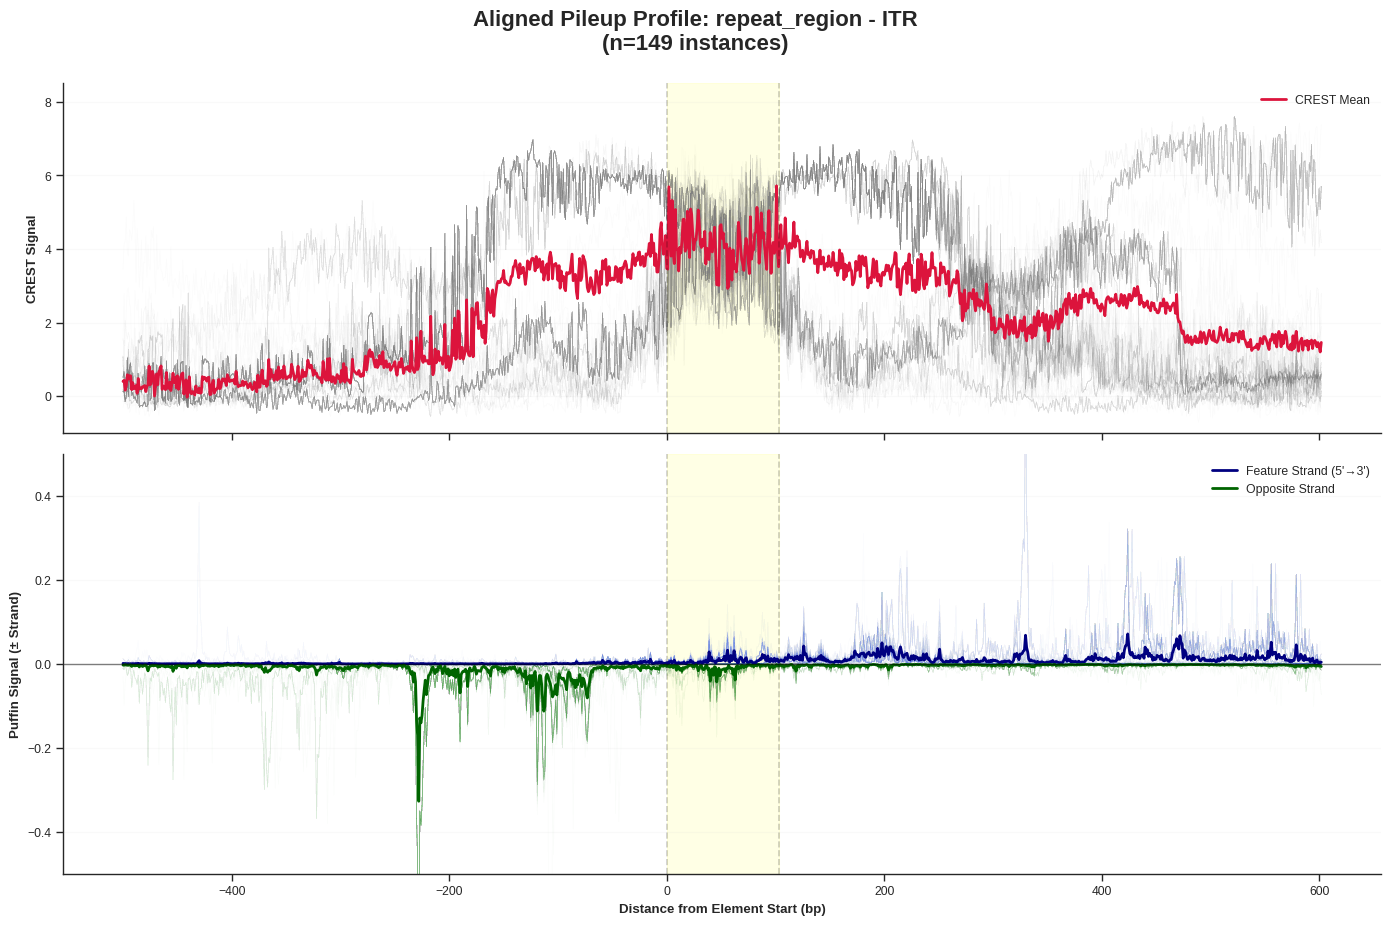

In [13]:
fig, (ax1, ax2) = plasmidtools.statplots.combined_prediction_pileups(pred_matrix, pred_fwd_matrix, pred_rev_matrix, element_type, element_name, flank_size)


**Plasmid Context**

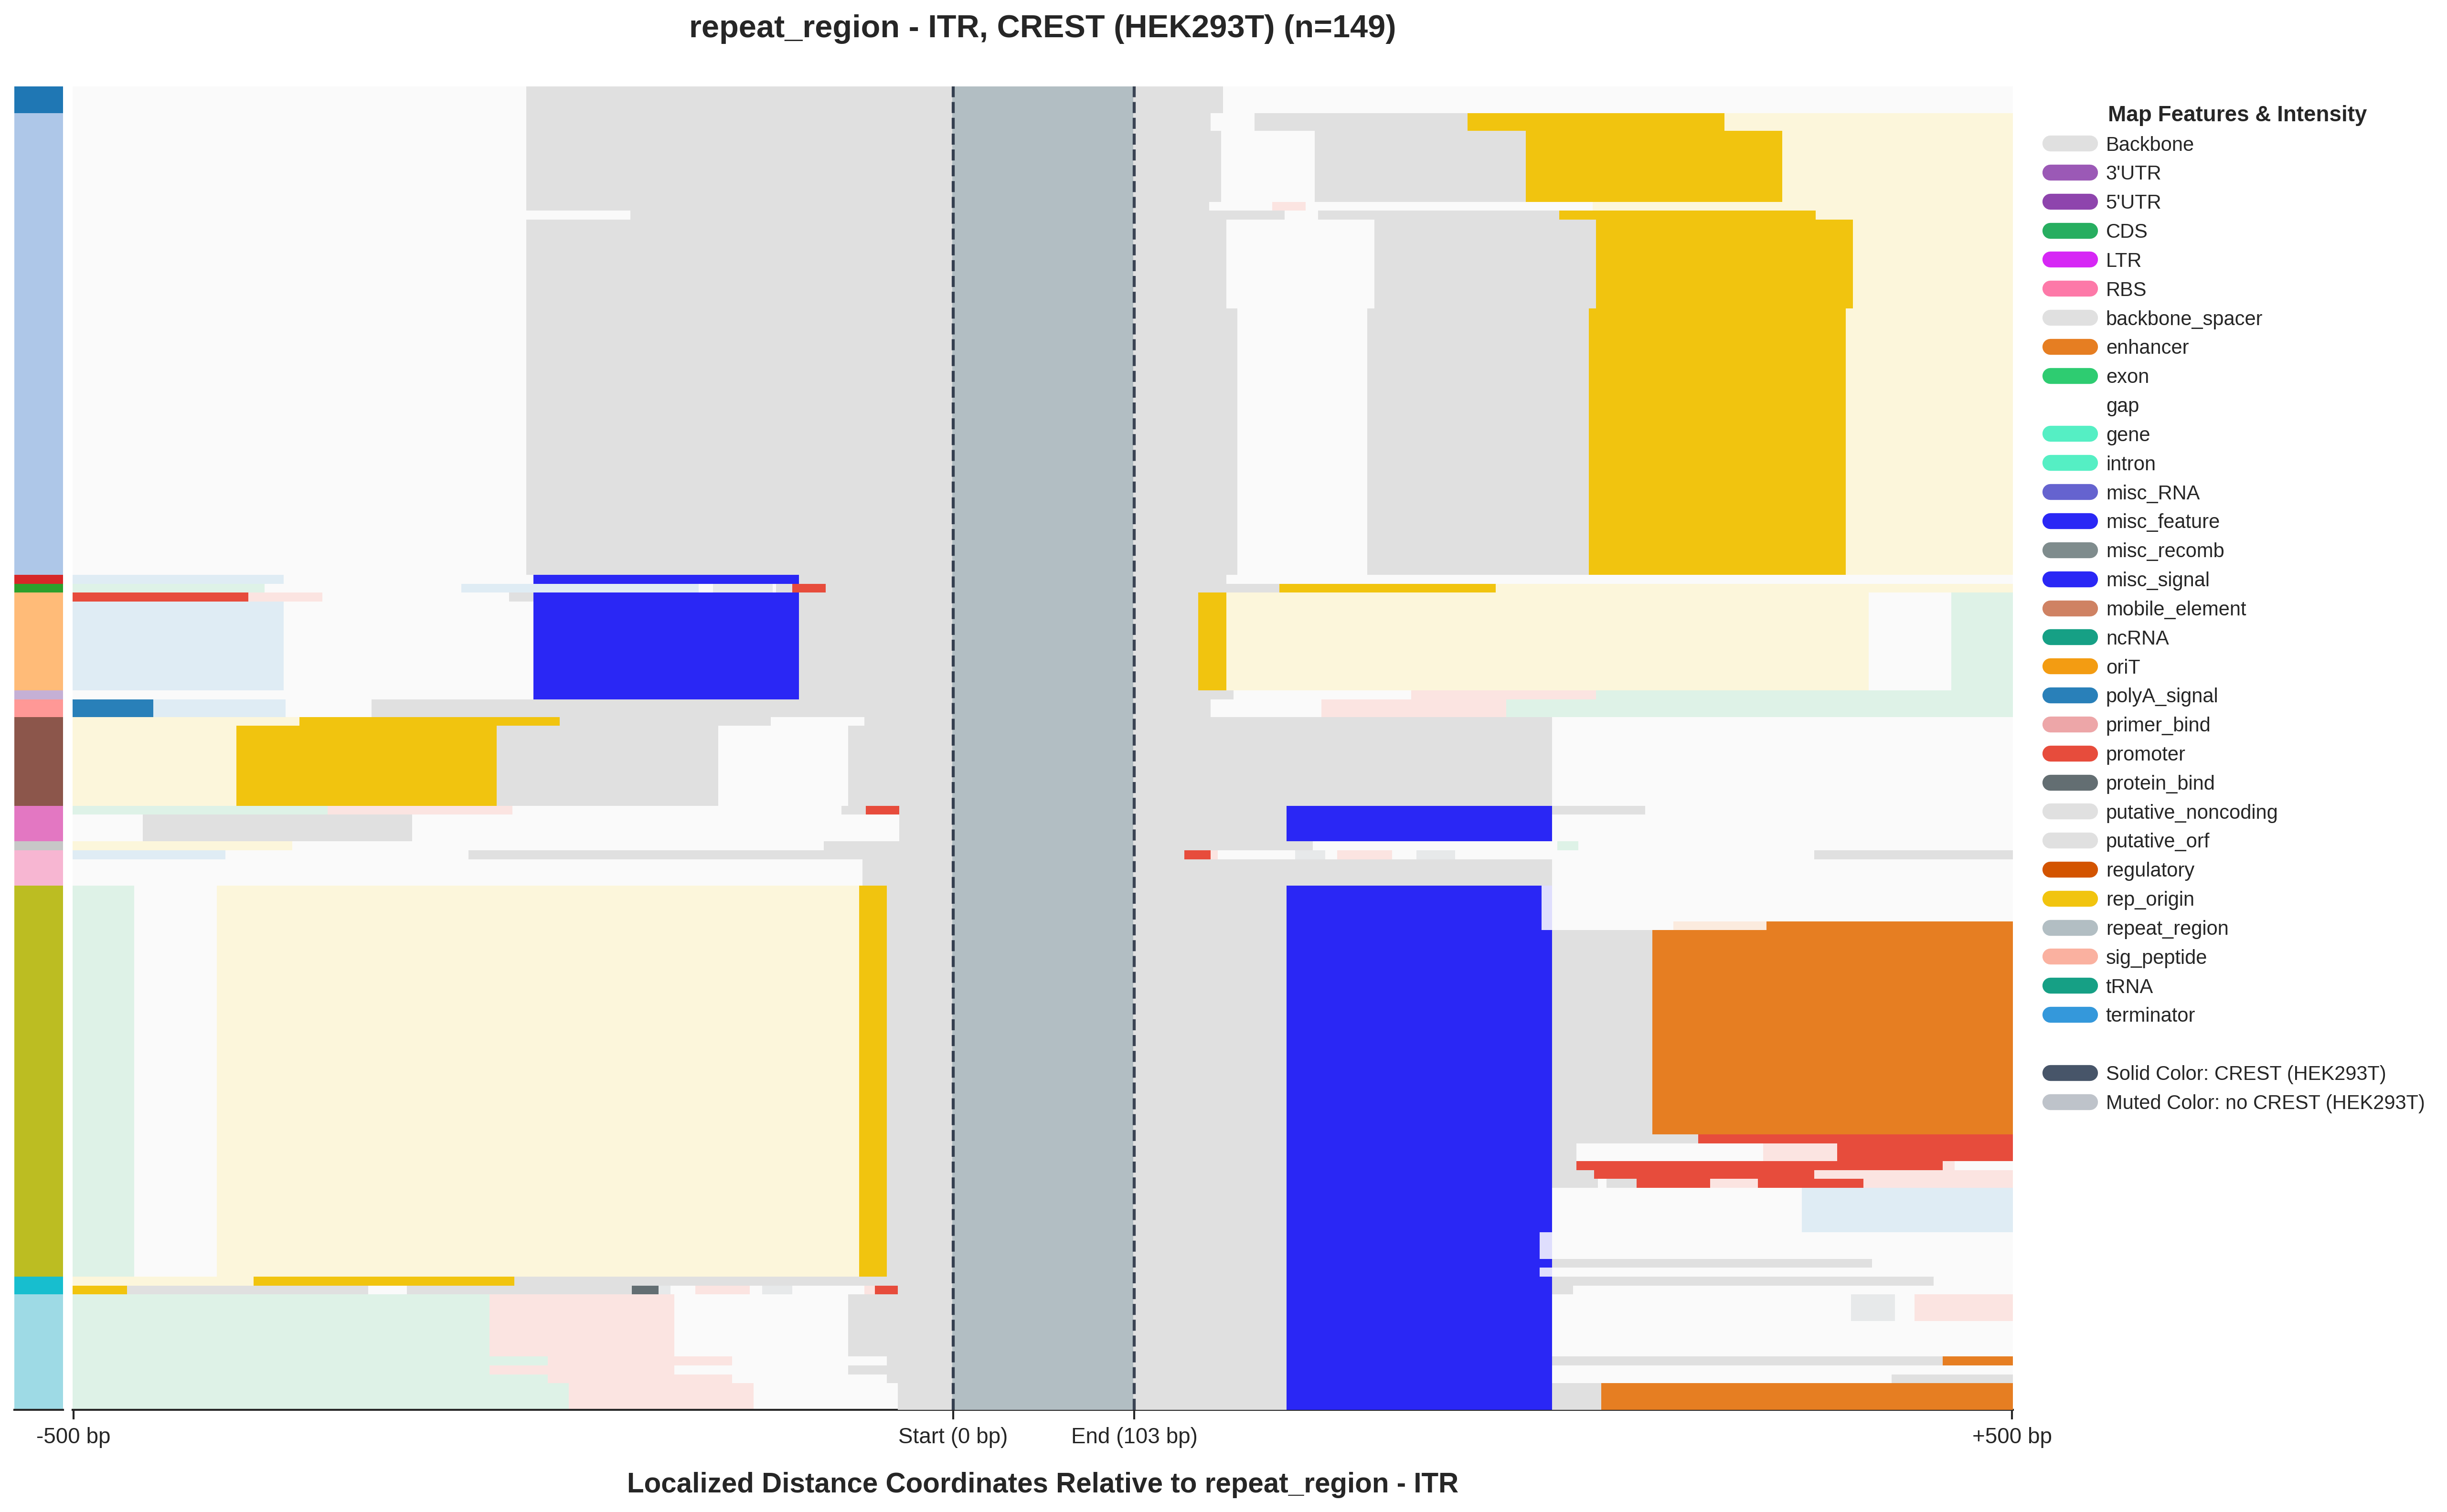

In [13]:
fig, ax = plasmidtools.statplots.element_centered_architecture_heatmap(
    type_matrix=type_matrix[:10000],
    flank_size=flank_size,
    element_size=element_size,
    cre_matrix=cre_matrix,
    cre_label="CREST (HEK293T)",
    target_label=f"{element_type} - {element_name}"
)


**Representative sequences**

Sequence representation

In [14]:
repr_seqs_dct = plasmidtools.helpers.load_representative_sequences(ADDGENE_DIR / "element_representative_sequences.fasta")
repr_seqs_cre = pl.read_parquet(ADDGENE_DIR / "element_representative_sequences_cre_overlaps.parquet")


In [15]:
repr_seqs_dct["rep_origin", "ori"]

{'sequence': 'GTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCGTATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAACTGTCAGACCAAGTTTACTCATATATACTTTAGATTGATTTAAAACTTCATTTTTAATTTAAAAGGATCTAGGTGAAGATCCTTTTTGATAATCTCATGACCAAAATCCCTTAACGTGAGTTTTCGTTCCACTGAGCGTCAGACCCCGTAGAAAAGATCAAAGGATCTTCTTGAGATCCTTTTTTTCTGCGCGTAATCTGCTGCTTGCAAACAAAAAAACCACCGCTACCAGCGGTGGTTTGTTTGCCGGATCAAGAGCTACCAACTCTTTTTCCGAAGGTAACTGGCTTCAGCAGAGCGCAGATACCAAATACTGTTCTTCTAGTGTAGCCGTAGTTAGGCCACCACTTCAAGAACTCTGTAGCACCGCCTACATACCTCGCTCTGCTAATCCTGTTACCAGTGGCTGCTGCCAGTGGCGATAAGTCGTGTCTTACCGGGTTGGACTCAAGACGATAGTTACCGGATAAGGCGCAGCGGTCGGGCTGAACGGGGGGTTCGTGCACACAGCCCAGCTTGGAGCGAACGACCTACACCGAACTGAGATACCTACAGCGTGAGCTATGAGAAAGCGCCACGCTTCCCGAAGGGAGAAAGGCGGACAGGTATCCGGTAAGCGGCAGGGTCGGAACAGGAGAGCGCACGAGGGAGCTTCCAGGGGGAAACGCCTGGTATCTTTATAGTCCTGTCGGGTTTCGCCACCTCTGACTTGAGCGTCGATTTTTGTGATGCTCGTCAGGGGGGCGGAGCCTATGGAAAAACGCCAGCAACGCGGCCTTTTTACGGTTCCTGGCCTTTTGCTGGCCTTTTGCTCACATGTTCTTTCCTGCG

In [ ]:
repr_meta = []
for (type, name) in cryptic_cre_candidates[["type", "name"]].rows():
    el_dct = repr_seqs_dct[(type, name)]
    repr_meta.append({
        "element_type": type,
        "element_name": name,
        "n_plasmids": el_dct["n_plasmids"],
        "n_citations": el_dct["n_citations"],
        "citation_frequency": el_dct["citation_frequency"],
        "plasmid_frequency": el_dct["plasmid_frequency"],
    })
repr_meta = pl.DataFrame(repr_meta)

repr_meta.sort("citation_frequency")

element_type,element_name,n_plasmids,n_citations,citation_frequency,plasmid_frequency
str,str,i64,i64,f64,f64
"""misc_feature""","""IRES""",18,271,0.0816,0.0063
"""CDS""","""mCerulean""",1,21,0.0833,0.0037
"""CDS""","""tTA""",1,10,0.0909,0.0079
"""CDS""","""SNAP-tag(R)""",1,10,0.0971,0.0065
"""CDS""","""ecDHFR""",1,5,0.1,0.0175
…,…,…,…,…,…
"""CDS""","""ABE(7.10)""",4,43,0.8269,0.3333
"""CDS""","""Cas9(H840A)""",17,155,0.8659,0.1717
"""CDS""","""CD63""",1,66,0.8684,0.0714


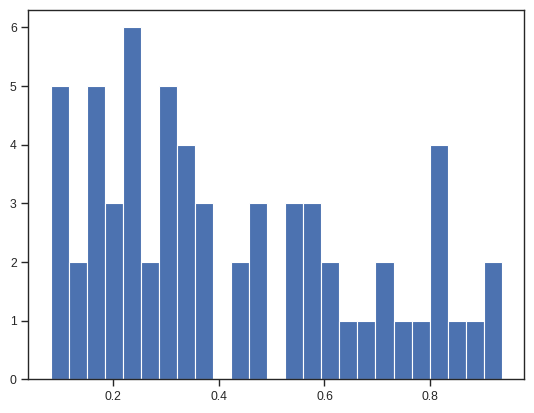

In [18]:
plt.hist(repr_meta["citation_frequency"], bins=25);

In [19]:
cryptic_cre_candidates

type,name,element_length,n_cre_midpoints,cre_avg_signal,fraction_cre_bp,n_tss_midpoints,tss_avg_signal,n_plasmids,n_citations,n_active_metrics,composite_z_score,priority_group,is_cryptic_cre
str,str,i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,i64,bool
"""misc_feature""","""Rosa26 left arm""",1083,1.166667,3.797483,0.931219,6.666667,0.097414,12,71,4,10.800964,1,true
"""rep_origin""","""SV40 ori""",136,0.10983,4.255939,0.999724,2.274575,0.138699,34641,42707,4,10.014389,1,true
"""intron""","""chimeric intron""",379,1.640152,1.770875,0.784054,0.953349,0.587276,4784,13160,4,9.798851,1,true
"""mobile_element""","""IS1""",768,1.507246,2.954059,0.48245,3.043478,0.080524,69,136,4,9.429387,1,true
"""LTR""","""3' LTR""",634,0.831852,3.744363,0.401137,0.632776,0.120348,2292,4079,5,7.155041,2,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CDS""","""SIRT1""",2241,1.0,1.366769,0.045844,0.090909,0.063711,11,78,1,1.551631,6,true
"""CDS""","""gag-pol""",5217,1.0,1.757834,0.024535,0.0,0.0,3,549,1,1.551631,6,true
"""CDS""","""large T antigen""",2127,1.0,0.973126,0.050964,0.0,0.0,15,276,1,1.551631,6,true


**Contribution Scores**

In [20]:
CONTRIBS_OUTPUT = ADDGENE_DIR / "CCCs_contrib_scores.h5"
PUFFIN_FLANK = 325

element_type, element_name = "misc_feature", "Rosa26 left arm"

element_seq_dct = repr_seqs_dct[(element_type, element_name)]
cre_positions = repr_seqs_cre.filter((pl.col("element_type") == element_type) & (pl.col('element_name') == element_name))["CREST (HEK293T)"][0].to_list()
tss_fwd_positions = repr_seqs_cre.filter((pl.col("element_type") == element_type) & (pl.col('element_name') == element_name))["Puffin (FANTOM_CAGE_fwd)"][0].to_list()
tss_rev_positions = repr_seqs_cre.filter((pl.col("element_type") == element_type) & (pl.col('element_name') == element_name))["Puffin (FANTOM_CAGE_rev)"][0].to_list()

contrib_scores = plasmidtools.helpers.load_contribution_scores(CONTRIBS_OUTPUT, element_type, element_name)

# print(contrib_scores['onehot'].shape)  # (4, L)
# print(contrib_scores['crest'].shape)  # (4, L); should be dot-producted with onehots
# print(contrib_scores['puffin_fwd'].shape)  # (L - 2 * PUFFIN_FLANK,); should be dot-producted with onehots
# print(contrib_scores['puffin_rev'].shape)  # (L - 2 * PUFFIN_FLANK,); should be dot-producted with onehots

cre_contribs = contrib_scores['onehot'] * contrib_scores['crest']
fwd_contribs = contrib_scores['onehot'][:, PUFFIN_FLANK: -PUFFIN_FLANK] * contrib_scores['puffin_fwd'][None, :]
rev_contribs = contrib_scores['onehot'][:, PUFFIN_FLANK: -PUFFIN_FLANK] * contrib_scores['puffin_rev'][None, :]

flank_size = element_seq_dct["flank_size"]
element_size = cre_contribs.shape[1] - 2 * flank_size


In [21]:
element_seq_dct

{'sequence': 'TATCTCGGTCTATTCTTTTGATTTATAAGGGATTTTGCCGATTTCGGCCTATTGGTTAAAAAATGAGCTGATTTAACAAAAATTTAACGCGAATTTTAACAAAATATTAACGCTTACAATTTCCATTCGCCATTCAGGCTGCGCAACTGTTGGGAAGGGCGATCGGTGCGGGCCTCTTCGCTATTACGCCAGCTGGCGAAAGGGGGATGTGCTGCAAGGCGATTAAGTTGGGTAACGCCAGGGTTTTCCCAGTCACGACGTTGTAAAACGACGGCCAGTGAGCGCGCGTAATACGACTCACTATAGGGCGAATTGGAGCTCCACCGCGGCAGGCCCTCCGAGCGTGGTGGAGCCGTTCTGTGAGACAGCCGGGTACGAGTCGTGACGCTGGAAGGGGCAAGCGGGTGGTGGGCAGGAATGCGGTCCGCCCTGCAGCAACCGGAGGGGGAGGGAGAAGGGAGCGGAAAAGTCTCCACCGGACGCGGCCATGGCTCGGGGGGGGGGGGGGGCAGCGGAGGAGCGCTTCCGGCCGACGTCTCGTCGCTGATTGGCTTCTTTTCCTCCCGCCGTGTGTGAAAACACAAATGGCGTGTTTTGGTTGGCGTAAGGCGCCTGTCAGTTAACGGCAGCCGGAGTGCGCAGCCGCCGGCAGCCTCGCTCTGCCCACTGGGTGGGGCGGGAGGTAGGTGGGGTGAGGCGAGCTGGACGTGCGGGCGCGGTCGGCCTCTGGCGGGGCGGGGGAGGGGAGGGAGGGTCAGCGAAAGTAGCTCGCGCGCGAGCGGCCGCCCACCCTCCCCTTCCTCTGGGGGAGTCGTTTTACCCGCCGCCGGCCGGGCCTCGTCGTCTGATTGGCTCTCGGGGCCCAGAAAACTGGCCCTTGCCATTGGCTCGTGTTCGTGCAAGTTGAGTCCATCCGCCGGCCAGCGGGGGCGGCGAGGAGGCGCTCCCAGGTTCCGGCCCTCCCCTCGGCCCCGCGCCGCAGAGTC

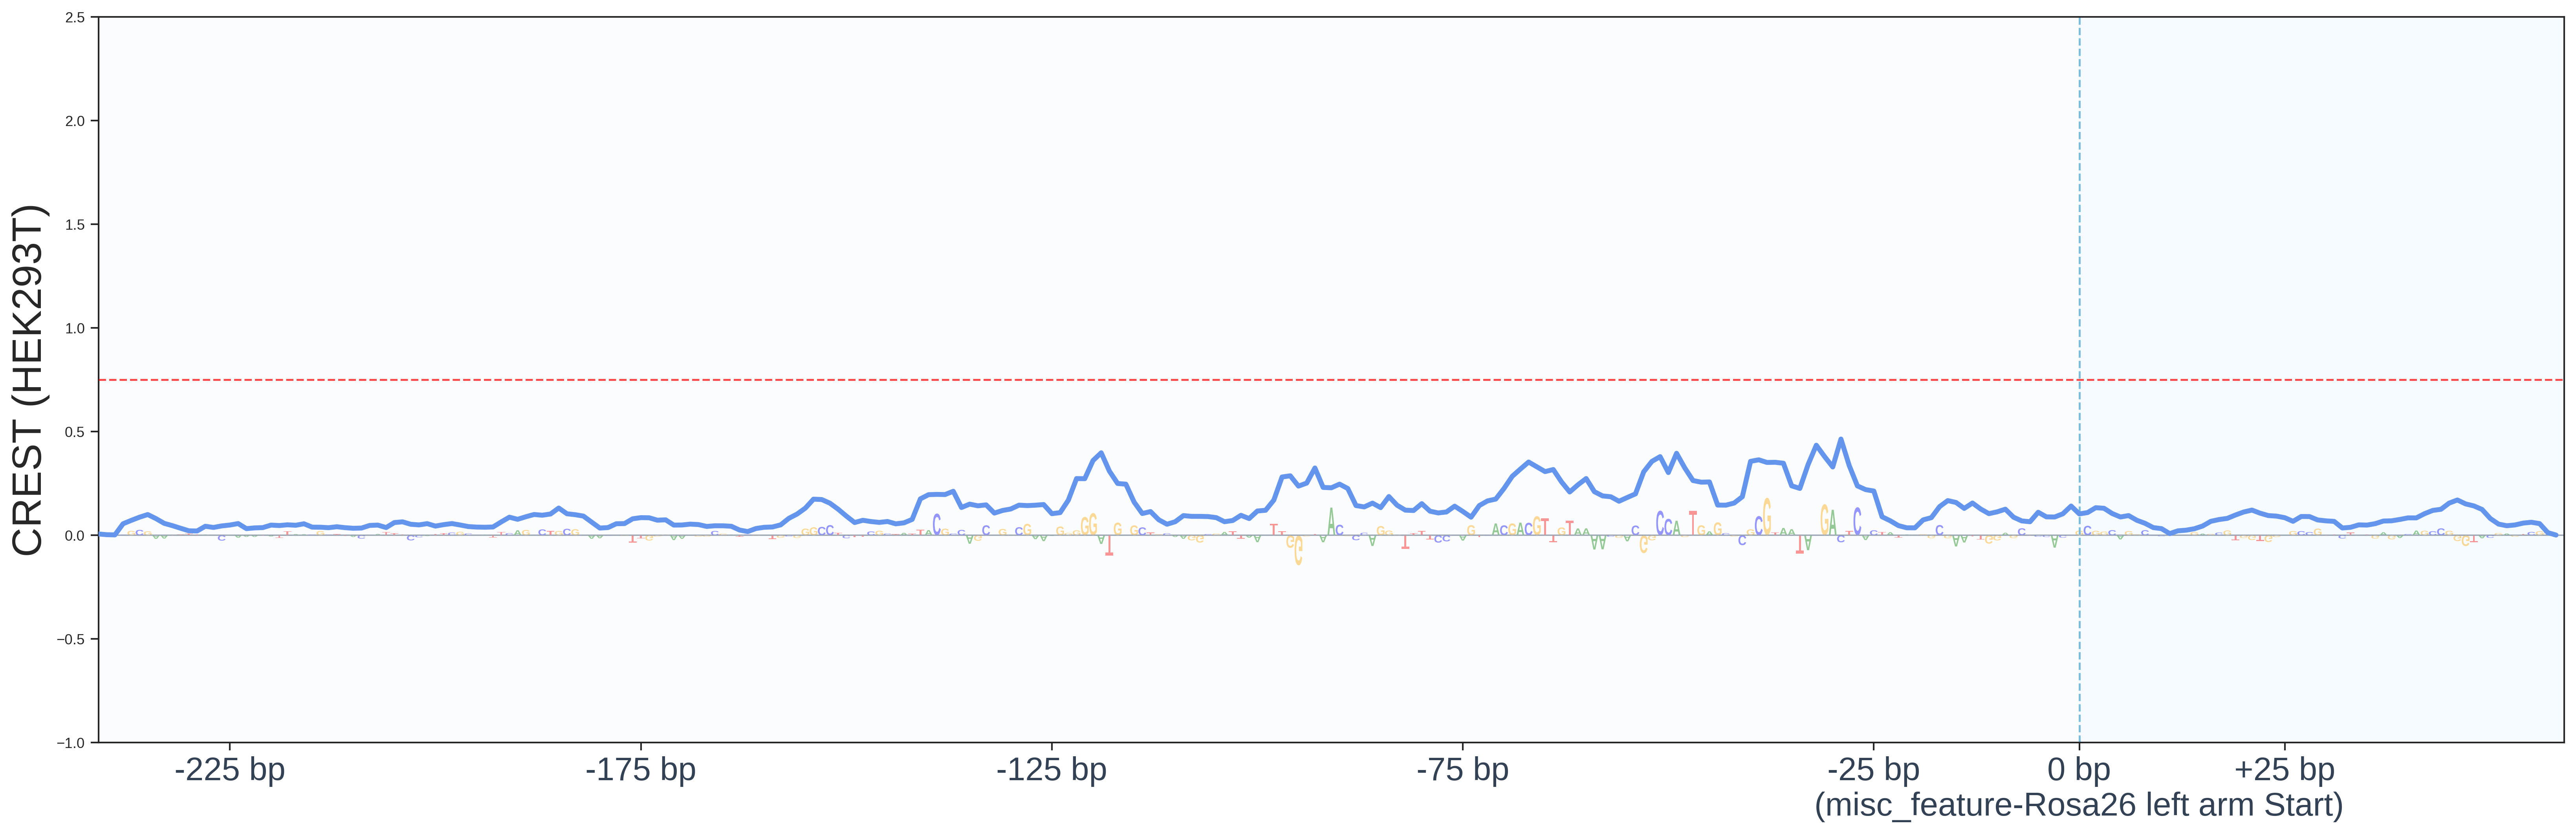

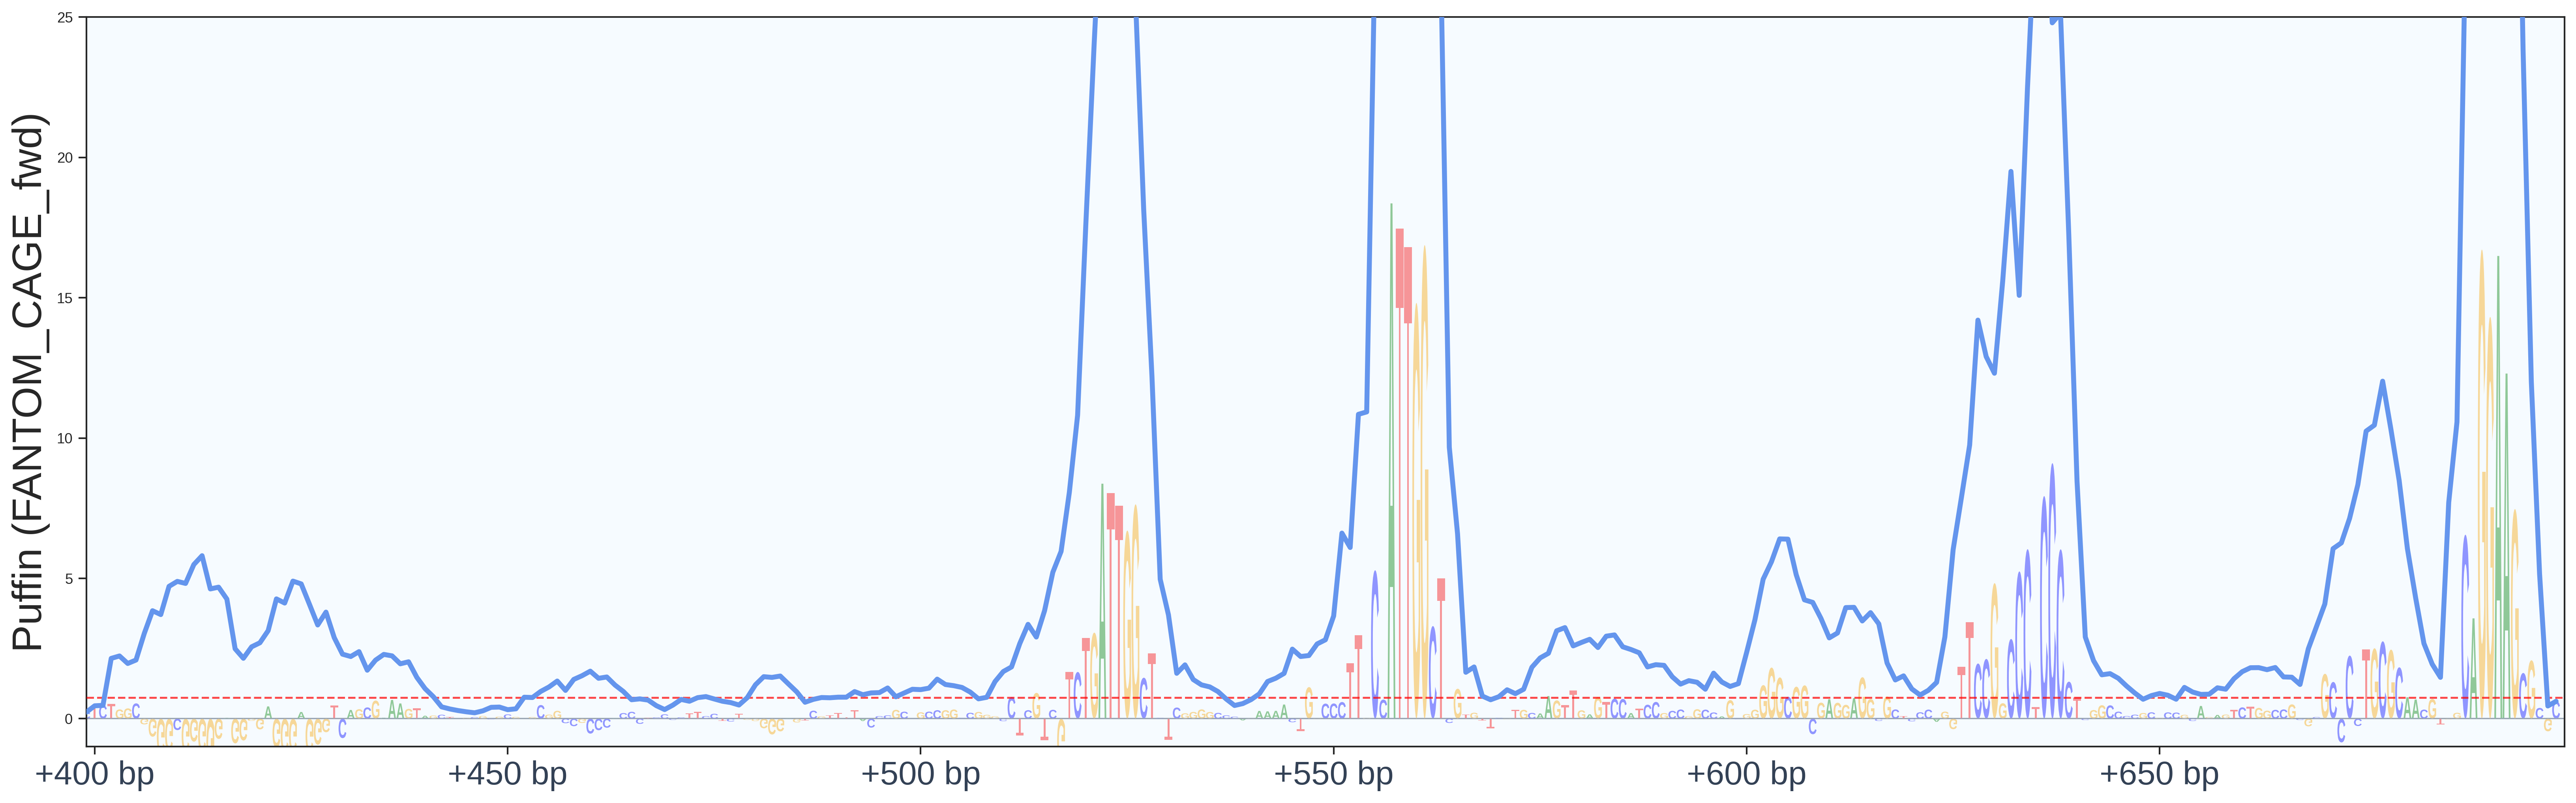

In [ ]:
if cre_positions:
    cre_start, cre_stop = cre_positions[0]  # TODO: iterate over all CREs
    mid = (cre_start + cre_stop) // 2
    start, stop = max(0, mid - 150), min(cre_contribs.shape[1], mid + 150)
    fig, ax = plasmidtools.contribplots.contribution_scores_plot(cre_contribs[:, start: stop])
    fig, ax = plasmidtools.contribplots.apply_element_annotations(fig, ax, slice_start=start, slice_end=stop, flank_size=flank_size, element_size=element_size, element_label=f"{element_type}-{element_name}")
    ax.set_ylabel("CREST (HEK293T)", fontsize=25)
    plt.show()
    plt.close()

if tss_fwd_positions:
    tss_start, tss_stop = tss_fwd_positions[0]  # TODO: iterate over all CREs
    mid = (tss_start + tss_stop) // 2
    start, stop = max(0, mid - 150), min(fwd_contribs.shape[1], mid + 150)
    fig, ax = plasmidtools.contribplots.contribution_scores_plot(fwd_contribs[:, start: stop], y_min=-1, y_max=25)
    fig, ax = plasmidtools.contribplots.apply_element_annotations(fig, ax, slice_start=start, slice_end=stop, flank_size=flank_size - PUFFIN_FLANK, element_size=element_size, element_label=f"{element_type}-{element_name}")
    ax.set_ylabel("Puffin (FANTOM_CAGE_fwd)", fontsize=25)
    plt.show()
